In [1]:
import warnings
warnings.filterwarnings('ignore')

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
filepath = "./data/GoNoGo_TRAINING_DATA.csv"
df = pd.read_csv(filepath)

In [4]:
df.head()

,APPLICATION.ID,DSA.ID,DEALER.ID,APP.DATE,TIME.STAMP,APPLICATION.STATUS,QUEUE.ID,CURRENT.STAGE,MARITAL.STATUS,GENDER,...,CREDIT.CARDS.CATEGORY,PRIMARY.ASSET.CTG,PRIMARY.ASSET.MAKE,PRIMARY.ASSET.MODELNO,VOTER_ID,DRIVING_LICENSE,AADHAAR,PAN,BANK_PASSBOOK,NoOfIds
0,27497000024,JB02005,27497,28-02-2017,22:11:01,Declined,Straight Through Process,PD_DE,Single,Male,...,NaN,REF-FF HOME,SAMSUNG,RT30K3723S8/HL,F,F,T,F,F,1
1,25556001005,RD02622,25556,28-02-2017,22:05:51,Approved,Straight Through Process,PD_DE,Married,Male,...,NaN,TELEVISION,SONY,KLV-29P423D,F,T,F,F,F,1
2,27220000249,SK02345,27220,28-02-2017,21:58:34,Approved,Straight Through Process,PD_DE,Married,Male,...,NaN,AIR CONDITIONER,ELECTROLUX,AIR CONDITIONER VANILLA,F,T,F,F,F,1
3,27067000029,DN30900,27067,28-02-2017,21:52:46,Declined,Under.Writer,DCLN,Married,Male,...,NaN,HOME THEATRE,TARGET,K1110 FM,F,F,T,F,F,1
4,26189000138,JB02005,26189,28-02-2017,21:52:33,Approved,Straight Through Process,APRV,Married,Male,...,NaN,SPLIT AC,ELECTROLUX,ES18T5C,F,F,F,T,F,1


In [5]:
df.shape

(7759, 47)

In [6]:
7156/7759

0.9222837994586931

In [7]:
df.columns

Index(['APPLICATION.ID', 'DSA.ID', 'DEALER.ID', 'APP.DATE', 'TIME.STAMP',
       'APPLICATION.STATUS', 'QUEUE.ID', 'CURRENT.STAGE', 'MARITAL.STATUS',
       'GENDER', 'AGE', 'EDUCATION', 'RESIDENCE.TYPE', 'CITY', 'STATE',
       'ZIP.CODE', 'EMPLOY.CONSTITUTION', 'NET.TAKE.HOME.SALARY', 'PAN.STATUS',
       'CIBIL.SCORE', 'APPLICATION.SCORE', 'RESIDENTIAL.ADDRESS.SCORE',
       'OFFICE.ADDRESS.SCORE', 'NAME.SCORE', 'APPROVED.AMOUNT', 'ASSET.MAKE',
       'ASSET.CTG', 'APPLIED.AMOUNT', 'LOAN.TENOR', 'LOAN.TYPE',
       'DEDUPE.REF.ID1', 'CAR.CATEGORY', 'OWN.HOUSE.TYPE',
       'HOUSE.SURROGATE.DOCUMENT.TYPE', 'TRADER.YEAR.IN.BUSINESS',
       'TRADER.BUSINESS.PROOF', 'CREDIT.CARD.NUMBER', 'CREDIT.CARDS.CATEGORY',
       'PRIMARY.ASSET.CTG', 'PRIMARY.ASSET.MAKE', 'PRIMARY.ASSET.MODELNO',
       'VOTER_ID', 'DRIVING_LICENSE', 'AADHAAR', 'PAN', 'BANK_PASSBOOK',
       'NoOfIds'],
      dtype='str')

In [8]:
df.isnull().sum()

APPLICATION.ID                      0
DSA.ID                              0
DEALER.ID                           0
APP.DATE                            0
TIME.STAMP                          0
APPLICATION.STATUS                  0
QUEUE.ID                            0
CURRENT.STAGE                       0
MARITAL.STATUS                      0
GENDER                              0
AGE                                 0
EDUCATION                           0
RESIDENCE.TYPE                      0
CITY                                0
STATE                               0
ZIP.CODE                            0
EMPLOY.CONSTITUTION                 0
NET.TAKE.HOME.SALARY             7156
PAN.STATUS                          1
CIBIL.SCORE                         0
APPLICATION.SCORE                   3
RESIDENTIAL.ADDRESS.SCORE        1624
OFFICE.ADDRESS.SCORE             1623
NAME.SCORE                       5372
APPROVED.AMOUNT                  4421
ASSET.MAKE                       4421
ASSET.CTG   

In [9]:
## if more than 50 % records have missing values then drop those columns
fifty_percent_count = int(df.shape[0]/2)
fifty_percent_count

3879

In [10]:
for column in df.columns:
    if df[column].isnull().sum() >= fifty_percent_count:
        df.drop([column],axis=1,inplace=True)

In [11]:
df.shape

(7759, 34)

In [12]:
df.isnull().sum()

APPLICATION.ID                  0
DSA.ID                          0
DEALER.ID                       0
APP.DATE                        0
TIME.STAMP                      0
APPLICATION.STATUS              0
QUEUE.ID                        0
CURRENT.STAGE                   0
MARITAL.STATUS                  0
GENDER                          0
AGE                             0
EDUCATION                       0
RESIDENCE.TYPE                  0
CITY                            0
STATE                           0
ZIP.CODE                        0
EMPLOY.CONSTITUTION             0
PAN.STATUS                      1
CIBIL.SCORE                     0
APPLICATION.SCORE               3
RESIDENTIAL.ADDRESS.SCORE    1624
OFFICE.ADDRESS.SCORE         1623
APPLIED.AMOUNT                  0
LOAN.TENOR                      0
LOAN.TYPE                       0
PRIMARY.ASSET.CTG               0
PRIMARY.ASSET.MAKE              0
PRIMARY.ASSET.MODELNO           0
VOTER_ID                        0
DRIVING_LICENS

In [13]:
df["PAN.STATUS"].value_counts()

PAN.STATUS
Pan Not Submitted    3331
EXIST                2387
ERROR                1842
NOT_FOUND             198
Name: count, dtype: int64

In [14]:
df["RESIDENTIAL.ADDRESS.SCORE"].mean()

61.94182396088019

In [15]:
df["RESIDENTIAL.ADDRESS.SCORE"] = df["RESIDENTIAL.ADDRESS.SCORE"].fillna(df["RESIDENTIAL.ADDRESS.SCORE"].mean(),inplace=True)

In [16]:
df["OFFICE.ADDRESS.SCORE"] = df["OFFICE.ADDRESS.SCORE"].fillna(df["OFFICE.ADDRESS.SCORE"].mean(),inplace=True)

In [17]:
## if there are very few records with missing values drop those rcords
df.dropna(inplace=True)

In [18]:
df.head()

,APPLICATION.ID,DSA.ID,DEALER.ID,APP.DATE,TIME.STAMP,APPLICATION.STATUS,QUEUE.ID,CURRENT.STAGE,MARITAL.STATUS,GENDER,...,LOAN.TYPE,PRIMARY.ASSET.CTG,PRIMARY.ASSET.MAKE,PRIMARY.ASSET.MODELNO,VOTER_ID,DRIVING_LICENSE,AADHAAR,PAN,BANK_PASSBOOK,NoOfIds
0,27497000024,JB02005,27497,28-02-2017,22:11:01,Declined,Straight Through Process,PD_DE,Single,Male,...,Consumer Durables,REF-FF HOME,SAMSUNG,RT30K3723S8/HL,F,F,T,F,F,1
1,25556001005,RD02622,25556,28-02-2017,22:05:51,Approved,Straight Through Process,PD_DE,Married,Male,...,Consumer Durables,TELEVISION,SONY,KLV-29P423D,F,T,F,F,F,1
2,27220000249,SK02345,27220,28-02-2017,21:58:34,Approved,Straight Through Process,PD_DE,Married,Male,...,Consumer Durables,AIR CONDITIONER,ELECTROLUX,AIR CONDITIONER VANILLA,F,T,F,F,F,1
3,27067000029,DN30900,27067,28-02-2017,21:52:46,Declined,Under.Writer,DCLN,Married,Male,...,Consumer Durables,HOME THEATRE,TARGET,K1110 FM,F,F,T,F,F,1
4,26189000138,JB02005,26189,28-02-2017,21:52:33,Approved,Straight Through Process,APRV,Married,Male,...,Consumer Durables,SPLIT AC,ELECTROLUX,ES18T5C,F,F,F,T,F,1


In [19]:
df["APPLICATION.STATUS"].value_counts()

APPLICATION.STATUS
Approved    4436
Declined    3319
Name: count, dtype: int64

In [20]:
X = df.drop(["APPLICATION.STATUS"],axis=1)
y = df["APPLICATION.STATUS"]

In [21]:
X["APPLICATION.SCORE"] = X["APPLICATION.SCORE"].replace("-",0)

In [22]:
X["APPLICATION.SCORE"] = X["APPLICATION.SCORE"].astype(float)

In [23]:
def CIBIL_SCORE(x):
    a=''
    if(x<=0):
        a='No History'
    elif(x>0 and x<=300):
        a='Very Poor'
    elif((x>300) and (x<=650)):
        a='Poor'
    elif((x>650) and (x<=750)):
        a='Good'
    elif((x>750) and (x<=900)):
        a='Excellent'
    else:
        a='Others'
    return a

In [24]:
X["CIBIL.SCORE"][0]

'734'

In [25]:
X["CIBIL.SCORE"] = X["CIBIL.SCORE"].replace("-",0)
X["CIBIL.SCORE"] = X["CIBIL.SCORE"].replace('000-1',-1)

In [26]:
X["CIBIL.SCORE"] = X["CIBIL.SCORE"].astype(int)
X["CIBIL.SCORE"] = X["CIBIL.SCORE"].apply(CIBIL_SCORE)

In [27]:
X["CIBIL.SCORE"].value_counts()

CIBIL.SCORE
No History    3376
Excellent     2792
Good           853
Poor           734
Name: count, dtype: int64

In [28]:
X["EDUCATION"] = X["EDUCATION"].apply(lambda x : "OTHERS" if x=="OTHERS" else "EDUCATED")

In [29]:
X["RESIDENCE.TYPE"] = X["RESIDENCE.TYPE"].apply(lambda x : "OWNED" if pd.Series(x).str.contains("OWNED")[0] else "RENTED")

In [30]:
X["RESIDENCE.TYPE"].value_counts()

RESIDENCE.TYPE
OWNED     5560
RENTED    2195
Name: count, dtype: int64

In [31]:
categorical_columns = X.columns[X.dtypes=='str']
Numerical_columns = X.columns[X.dtypes!='str']

In [32]:
categorical_columns

Index(['DSA.ID', 'APP.DATE', 'TIME.STAMP', 'QUEUE.ID', 'CURRENT.STAGE',
       'MARITAL.STATUS', 'GENDER', 'EDUCATION', 'RESIDENCE.TYPE', 'CITY',
       'STATE', 'EMPLOY.CONSTITUTION', 'PAN.STATUS', 'CIBIL.SCORE',
       'LOAN.TYPE', 'PRIMARY.ASSET.CTG', 'PRIMARY.ASSET.MAKE',
       'PRIMARY.ASSET.MODELNO', 'VOTER_ID', 'DRIVING_LICENSE', 'AADHAAR',
       'PAN', 'BANK_PASSBOOK'],
      dtype='str')

In [33]:
X[categorical_columns].head()

,DSA.ID,APP.DATE,TIME.STAMP,QUEUE.ID,CURRENT.STAGE,MARITAL.STATUS,GENDER,EDUCATION,RESIDENCE.TYPE,CITY,...,CIBIL.SCORE,LOAN.TYPE,PRIMARY.ASSET.CTG,PRIMARY.ASSET.MAKE,PRIMARY.ASSET.MODELNO,VOTER_ID,DRIVING_LICENSE,AADHAAR,PAN,BANK_PASSBOOK
0,JB02005,28-02-2017,22:11:01,Straight Through Process,PD_DE,Single,Male,EDUCATED,OWNED,UDHANA,...,Good,Consumer Durables,REF-FF HOME,SAMSUNG,RT30K3723S8/HL,F,F,T,F,F
1,RD02622,28-02-2017,22:05:51,Straight Through Process,PD_DE,Married,Male,OTHERS,OWNED,BHOPAL,...,Excellent,Consumer Durables,TELEVISION,SONY,KLV-29P423D,F,T,F,F,F
2,SK02345,28-02-2017,21:58:34,Straight Through Process,PD_DE,Married,Male,EDUCATED,OWNED,RAIPUR,...,Excellent,Consumer Durables,AIR CONDITIONER,ELECTROLUX,AIR CONDITIONER VANILLA,F,T,F,F,F
3,DN30900,28-02-2017,21:52:46,Under.Writer,DCLN,Married,Male,EDUCATED,OWNED,JAMNAGAR,...,No History,Consumer Durables,HOME THEATRE,TARGET,K1110 FM,F,F,T,F,F
4,JB02005,28-02-2017,21:52:33,Straight Through Process,APRV,Married,Male,EDUCATED,OWNED,UDHANA,...,Excellent,Consumer Durables,SPLIT AC,ELECTROLUX,ES18T5C,F,F,F,T,F


In [34]:
X["QUEUE.ID"].value_counts()

QUEUE.ID
Straight  Through Process    5371
Under.Writer                 2384
Name: count, dtype: int64

In [35]:
X["LOAN.TYPE"].value_counts()

LOAN.TYPE
Consumer Durables    7755
Name: count, dtype: int64

In [36]:
X["CURRENT.STAGE"].value_counts()

CURRENT.STAGE
PD_DE        2556
DCLN         2120
APRV         1107
INV_GNR       855
LOS_DISB      730
SRNV          295
LOS_BDE        86
LOS_ERROR       6
Name: count, dtype: int64

In [37]:
X["PRIMARY.ASSET.MODELNO"].value_counts()

PRIMARY.ASSET.MODELNO
KLV-40W562D                       186
UA32K5300ARLXL                    143
REFRIGERATORS VANILLA             142
GL-U372HPBL                       137
K1110 FM                          111
                                 ... 
GSC 18 TSZ 5 RWPT  5N3N 5* 1.5      1
AR18FC3EGBH 1.5 T                   1
HDR-PJ670BC  E35                    1
UA28J4100ARLXL                      1
ES18M5C-W 1.5 TON                   1
Name: count, Length: 1893, dtype: int64

In [38]:
X["DEALER.ID"].value_counts()

DEALER.ID
26563    78
25052    72
26560    60
25150    58
25556    55
         ..
26858     1
28176     1
27644     1
27273     1
27859     1
Name: count, Length: 1095, dtype: int64

In [39]:
X.columns

Index(['APPLICATION.ID', 'DSA.ID', 'DEALER.ID', 'APP.DATE', 'TIME.STAMP',
       'QUEUE.ID', 'CURRENT.STAGE', 'MARITAL.STATUS', 'GENDER', 'AGE',
       'EDUCATION', 'RESIDENCE.TYPE', 'CITY', 'STATE', 'ZIP.CODE',
       'EMPLOY.CONSTITUTION', 'PAN.STATUS', 'CIBIL.SCORE', 'APPLICATION.SCORE',
       'RESIDENTIAL.ADDRESS.SCORE', 'OFFICE.ADDRESS.SCORE', 'APPLIED.AMOUNT',
       'LOAN.TENOR', 'LOAN.TYPE', 'PRIMARY.ASSET.CTG', 'PRIMARY.ASSET.MAKE',
       'PRIMARY.ASSET.MODELNO', 'VOTER_ID', 'DRIVING_LICENSE', 'AADHAAR',
       'PAN', 'BANK_PASSBOOK', 'NoOfIds'],
      dtype='str')

In [40]:
X.drop(["DSA.ID","APP.DATE","TIME.STAMP","LOAN.TYPE","CURRENT.STAGE","QUEUE.ID"],axis=1,inplace=True)

In [41]:
categorical_columns = X.columns[X.dtypes=='str']
Numerical_columns = X.columns[X.dtypes!='str']
X_categorical = X[categorical_columns]

## Categorical Features

## Chi2 test

In [43]:
from sklearn.feature_selection import chi2,mutual_info_classif

In [44]:
X_categorical.head()

,MARITAL.STATUS,GENDER,EDUCATION,RESIDENCE.TYPE,CITY,STATE,EMPLOY.CONSTITUTION,PAN.STATUS,CIBIL.SCORE,PRIMARY.ASSET.CTG,PRIMARY.ASSET.MAKE,PRIMARY.ASSET.MODELNO,VOTER_ID,DRIVING_LICENSE,AADHAAR,PAN,BANK_PASSBOOK
0,Single,Male,EDUCATED,OWNED,UDHANA,GUJARAT,SELF-EMPLOYED,Pan Not Submitted,Good,REF-FF HOME,SAMSUNG,RT30K3723S8/HL,F,F,T,F,F
1,Married,Male,OTHERS,OWNED,BHOPAL,MADHYA PRADESH,SELF-EMPLOYED,Pan Not Submitted,Excellent,TELEVISION,SONY,KLV-29P423D,F,T,F,F,F
2,Married,Male,EDUCATED,OWNED,RAIPUR,CHHATTISGARH,SELF-EMPLOYED,Pan Not Submitted,Excellent,AIR CONDITIONER,ELECTROLUX,AIR CONDITIONER VANILLA,F,T,F,F,F
3,Married,Male,EDUCATED,OWNED,JAMNAGAR,GUJARAT,SELF-EMPLOYED,Pan Not Submitted,No History,HOME THEATRE,TARGET,K1110 FM,F,F,T,F,F
4,Married,Male,EDUCATED,OWNED,UDHANA,GUJARAT,SALARIED,ERROR,Excellent,SPLIT AC,ELECTROLUX,ES18T5C,F,F,F,T,F


In [45]:
# pd.get_dummies??

In [46]:
X_encoded = pd.get_dummies(X_categorical,drop_first=True)

In [47]:
chi2??

Signature: chi2(X, y)
Source:   
@validate_params(
    {
        "X": ["array-like", "sparse matrix"],
        "y": ["array-like"],
    },
    prefer_skip_nested_validation=True,
)
def chi2(X, y):
    """Compute chi-squared stats between each non-negative feature and class.

    This score can be used to select the `n_features` features with the
    highest values for the test chi-squared statistic from X, which must
    contain only **non-negative integer feature values** such as booleans or frequencies
    (e.g., term counts in document classification), relative to the classes.

    If some of your features are continuous, you need to bin them, for
    example by using :class:`~sklearn.preprocessing.KBinsDiscretizer`.

    Recall that the chi-square test measures dependence between stochastic
    variables, so using this function "weeds out" the features that are the
    most likely to be independent of class and therefore irrelevant for
    classification.

    Read more in the :ref

In [48]:
chi2_stats, p_values = chi2(X_encoded, y)

In [49]:
chi2_stats

array([ 7.12106007,  0.07772217, 14.20439239, ...,  0.97268963,
        2.78533499,  6.11666222])

In [50]:
df_cat = pd.DataFrame()
df_cat["columns"] = X_encoded.columns
df_cat["chi2_stats"] = chi2_stats
df_cat["p_values"] = p_values

In [51]:
df_cat.head()

,columns,chi2_stats,p_values
0,MARITAL.STATUS_Single,7.121060,7.618365e-03
1,GENDER_Male,0.077722,7.804083e-01
2,EDUCATION_OTHERS,14.204392,1.639873e-04
3,RESIDENCE.TYPE_RENTED,137.253890,1.061123e-31
4,CITY_A.B.V. TOWNSHIP DURGAPUR,1.396257,2.373513e-01


In [52]:
df_cat[df_cat["p_values"]<=0.05]

,columns,chi2_stats,p_values
0,MARITAL.STATUS_Single,7.121060,7.618365e-03
2,EDUCATION_OTHERS,14.204392,1.639873e-04
3,RESIDENCE.TYPE_RENTED,137.253890,1.061123e-31
7,CITY_AGASTEESWARAM,4.026979,4.477805e-02
8,CITY_AHMEDABAD,4.698040,3.019703e-02
...,...,...,...
2300,PRIMARY.ASSET.MODELNO_VP242P,4.498177,3.393100e-02
2324,PRIMARY.ASSET.MODELNO_VSZ55.WV1,8.230162,4.119985e-03
2354,PRIMARY.ASSET.MODELNO_WA65K4020HL/TL,6.682736,9.735110e-03
2445,PRIMARY.ASSET.MODELNO_WW85H7410EW/TL,5.346189,2.076762e-02


In [53]:
mi_scores = mutual_info_classif(X_encoded, y, discrete_features=True)

df_cat_mi = pd.DataFrame()
df_cat_mi["columns"] = X_encoded.columns
df_cat_mi["mi_score"] = mi_scores

In [54]:
df_cat_mi.head()

,columns,mi_score
0,MARITAL.STATUS_Single,0.000567
1,GENDER_Male,0.000031
2,EDUCATION_OTHERS,0.001080
3,RESIDENCE.TYPE_RENTED,0.012262
4,CITY_A.B.V. TOWNSHIP DURGAPUR,0.000089


In [55]:
rcombined_df = df_cat.merge(df_cat_mi,on="columns")

In [56]:
rcombined_df.head()

,columns,chi2_stats,p_values,mi_score
0,MARITAL.STATUS_Single,7.121060,7.618365e-03,0.000567
1,GENDER_Male,0.077722,7.804083e-01,0.000031
2,EDUCATION_OTHERS,14.204392,1.639873e-04,0.001080
3,RESIDENCE.TYPE_RENTED,137.253890,1.061123e-31,0.012262
4,CITY_A.B.V. TOWNSHIP DURGAPUR,1.396257,2.373513e-01,0.000089


In [57]:
relevant_df = rcombined_df[rcombined_df["p_values"]<=0.05]

In [58]:
relevant_df.head()

,columns,chi2_stats,p_values,mi_score
0,MARITAL.STATUS_Single,7.121060,7.618365e-03,0.000567
2,EDUCATION_OTHERS,14.204392,1.639873e-04,0.001080
3,RESIDENCE.TYPE_RENTED,137.253890,1.061123e-31,0.012262
7,CITY_AGASTEESWARAM,4.026979,4.477805e-02,0.000271
8,CITY_AHMEDABAD,4.698040,3.019703e-02,0.000324


In [59]:
relevant_sorted = relevant_df.sort_values(by="mi_score",ascending=False)

In [60]:
relevant_sorted.head(20)

,columns,chi2_stats,p_values,mi_score
454,CIBIL.SCORE_Poor,981.025610,2.391409e-215,0.087034
452,CIBIL.SCORE_Good,812.578968,9.935588e-179,0.064027
3,RESIDENCE.TYPE_RENTED,137.253890,1.061123e-31,0.012262
140,CITY_HYDERABAD,43.461912,4.322920e-11,0.003058
442,STATE_TELANGANA,43.461912,4.322920e-11,0.003058
444,STATE_WEST BENGAL,37.294262,1.015831e-09,0.002735
436,STATE_GUJARAT,23.648534,1.156340e-06,0.001839
439,STATE_MADHYA PRADESH,24.211310,8.632387e-07,0.001781
438,STATE_KARNATAKA,25.300468,4.905897e-07,0.001675
453,CIBIL.SCORE_No History,12.375071,4.351043e-04,0.001412


In [61]:
relevant_sorted.shape

(101, 4)

In [62]:
relevant_sorted.to_excel("Go_No_Go_Categorical_analysis.xlsx")

In [63]:
rel_cols = []
for column in X_categorical.columns:
    if relevant_sorted["columns"].str.contains(column).sum()>0:
        rel_cols.append(column)

In [64]:
rel_cols

['MARITAL.STATUS',
 'EDUCATION',
 'RESIDENCE.TYPE',
 'CITY',
 'STATE',
 'PAN.STATUS',
 'CIBIL.SCORE',
 'PRIMARY.ASSET.CTG',
 'PRIMARY.ASSET.MAKE',
 'PRIMARY.ASSET.MODELNO',
 'PAN',
 'BANK_PASSBOOK']

In [65]:
pd.crosstab(X_categorical["PAN"],X_categorical["PAN.STATUS"])

PAN.STATUS,ERROR,EXIST,NOT_FOUND,Pan Not Submitted
PAN,,,,
F,0,0,0,3311
T,1842,2386,198,18


In [66]:
X_categorical['MARITAL.STATUS'].value_counts()

MARITAL.STATUS
Married    6253
Single     1502
Name: count, dtype: int64

In [67]:
X_categorical['EDUCATION'].value_counts()

EDUCATION
EDUCATED    6529
OTHERS      1226
Name: count, dtype: int64

In [68]:
X_categorical['RESIDENCE.TYPE'].value_counts()

RESIDENCE.TYPE
OWNED     5560
RENTED    2195
Name: count, dtype: int64

In [69]:
X_categorical['BANK_PASSBOOK'].value_counts()

BANK_PASSBOOK
F    7413
T     342
Name: count, dtype: int64

In [70]:
y.value_counts()

APPLICATION.STATUS
Approved    4436
Declined    3319
Name: count, dtype: int64

In [71]:
pd.crosstab(X_categorical["BANK_PASSBOOK"],y)

APPLICATION.STATUS,Approved,Declined
BANK_PASSBOOK,,
F,4263,3150
T,173,169


In [72]:
pd.crosstab(X_categorical["EDUCATION"],y)

APPLICATION.STATUS,Approved,Declined
EDUCATION,,
EDUCATED,3800,2729
OTHERS,636,590


In [73]:
rel_columns = ['MARITAL.STATUS','EDUCATION','RESIDENCE.TYPE','CIBIL.SCORE','PAN']

In [74]:
rel_columns

['MARITAL.STATUS', 'EDUCATION', 'RESIDENCE.TYPE', 'CIBIL.SCORE', 'PAN']

In [75]:
X_cat_rel = X[rel_columns]

In [76]:
X_encoded_rel = pd.get_dummies(X_cat_rel,drop_first=True)
chi2_stats, p_values = chi2(X_encoded_rel, y)
df_cat = pd.DataFrame()
df_cat["columns"] = X_encoded_rel.columns
df_cat["chi2_stats"] = chi2_stats
df_cat["p_values"] = p_values

In [77]:
mi_scores = mutual_info_classif(X_encoded_rel, y, discrete_features=True)

df_cat_mi = pd.DataFrame()
df_cat_mi["columns"] = X_encoded_rel.columns
df_cat_mi["mi_score"] = mi_scores

In [78]:
rcombined_df = df_cat.merge(df_cat_mi,on="columns")
relevant_df = rcombined_df[rcombined_df["p_values"]<=0.05]


In [79]:
relevant_df

,columns,chi2_stats,p_values,mi_score
0,MARITAL.STATUS_Single,7.121060,7.618365e-03,0.000567
1,EDUCATION_OTHERS,14.204392,1.639873e-04,0.001080
2,RESIDENCE.TYPE_RENTED,137.253890,1.061123e-31,0.012262
3,CIBIL.SCORE_Good,812.578968,9.935588e-179,0.064027
4,CIBIL.SCORE_No History,12.375071,4.351043e-04,0.001412
5,CIBIL.SCORE_Poor,981.025610,2.391409e-215,0.087034


In [307]:
categorical_columns

Index(['MARITAL.STATUS', 'GENDER', 'EDUCATION', 'RESIDENCE.TYPE', 'CITY',
       'STATE', 'EMPLOY.CONSTITUTION', 'PAN.STATUS', 'CIBIL.SCORE',
       'PRIMARY.ASSET.CTG', 'PRIMARY.ASSET.MAKE', 'PRIMARY.ASSET.MODELNO',
       'VOTER_ID', 'DRIVING_LICENSE', 'AADHAAR', 'PAN', 'BANK_PASSBOOK'],
      dtype='str')

In [ ]:
["EDUCATION","RESIDENCE.TYPE","CIBIL.SCORE"]

## Numerical features

In [248]:
Numerical_columns

Index(['APPLICATION.ID', 'DEALER.ID', 'AGE', 'ZIP.CODE', 'APPLICATION.SCORE',
       'RESIDENTIAL.ADDRESS.SCORE', 'OFFICE.ADDRESS.SCORE', 'APPLIED.AMOUNT',
       'LOAN.TENOR', 'NoOfIds'],
      dtype='str')

In [250]:
X_numerical = X[Numerical_columns]

In [252]:
X_numerical["target"] = y.apply(lambda x : 1 if x == "Approved" else 0)

In [254]:
X_numerical.corr()

,APPLICATION.ID,DEALER.ID,AGE,ZIP.CODE,APPLICATION.SCORE,RESIDENTIAL.ADDRESS.SCORE,OFFICE.ADDRESS.SCORE,APPLIED.AMOUNT,LOAN.TENOR,NoOfIds,target
APPLICATION.ID,1.000000,1.000000,-0.002859,-0.331193,-0.008450,0.007078,0.048167,-0.087210,0.017422,0.140508,0.007534
DEALER.ID,1.000000,1.000000,-0.002859,-0.331193,-0.008450,0.007078,0.048167,-0.087210,0.017422,0.140508,0.007534
AGE,-0.002859,-0.002859,1.000000,0.075442,0.167532,-0.004952,0.048834,0.070086,0.005386,-0.061404,0.006529
ZIP.CODE,-0.331193,-0.331193,0.075442,1.000000,0.008255,0.065227,0.029921,0.104888,0.040649,-0.067095,0.007937
APPLICATION.SCORE,-0.008450,-0.008450,0.167532,0.008255,1.000000,-0.056757,-0.001929,0.089787,-0.018437,-0.020287,0.168473
RESIDENTIAL.ADDRESS.SCORE,0.007078,0.007078,-0.004952,0.065227,-0.056757,1.000000,0.460611,0.031398,0.011382,0.018107,-0.022856
OFFICE.ADDRESS.SCORE,0.048167,0.048167,0.048834,0.029921,-0.001929,0.460611,1.000000,0.006021,0.007987,0.005618,-0.007820
APPLIED.AMOUNT,-0.087210,-0.087210,0.070086,0.104888,0.089787,0.031398,0.006021,1.000000,0.027896,0.046329,-0.033762
LOAN.TENOR,0.017422,0.017422,0.005386,0.040649,-0.018437,0.011382,0.007987,0.027896,1.000000,-0.011398,0.009090
NoOfIds,0.140508,0.140508,-0.061404,-0.067095,-0.020287,0.018107,0.005618,0.046329,-0.011398,1.000000,-0.041502


In [256]:
X_numerical_selected = X_numerical[["AGE","APPLICATION.SCORE","RESIDENTIAL.ADDRESS.SCORE","APPLIED.AMOUNT","LOAN.TENOR","NoOfIds","target"]]

In [258]:
mi_scores = mutual_info_classif(X_numerical_selected, y, discrete_features=True)

df_cat_mi = pd.DataFrame()
df_cat_mi["columns"] = X_numerical_selected.columns
df_cat_mi["mi_score"] = mi_scores

In [260]:
df_cat_mi

,columns,mi_score
0,AGE,0.009421
1,APPLICATION.SCORE,0.080887
2,RESIDENTIAL.ADDRESS.SCORE,0.204728
3,APPLIED.AMOUNT,0.040110
4,LOAN.TENOR,0.003055
5,NoOfIds,0.001144
6,target,0.682738


<Axes: xlabel='AGE', ylabel='Density'>

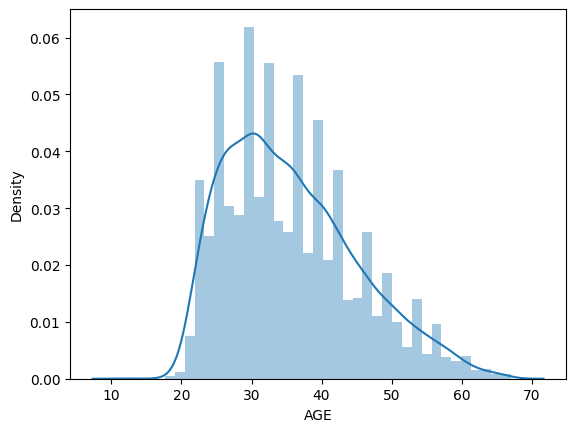

In [262]:
sns.distplot(X_numerical["AGE"])

<Axes: xlabel='APPLICATION.SCORE', ylabel='Density'>

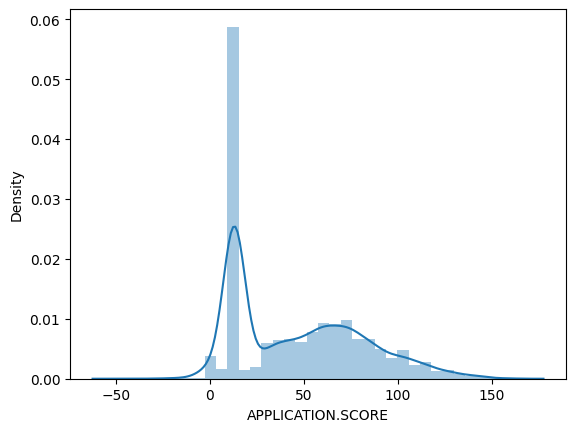

In [264]:
sns.distplot(X_numerical["APPLICATION.SCORE"])

<Axes: xlabel='RESIDENTIAL.ADDRESS.SCORE', ylabel='Density'>

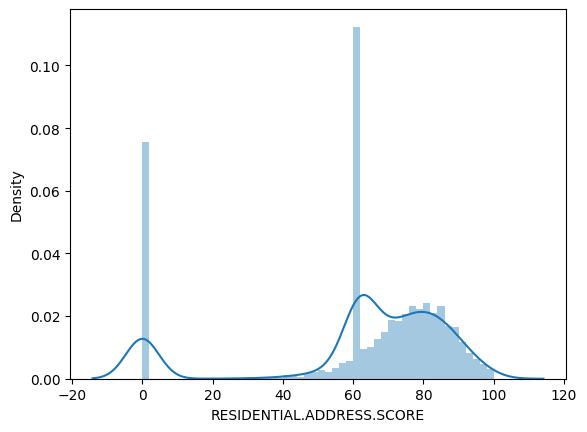

In [266]:
sns.distplot(X_numerical["RESIDENTIAL.ADDRESS.SCORE"])

<Axes: xlabel='APPLIED.AMOUNT', ylabel='Density'>

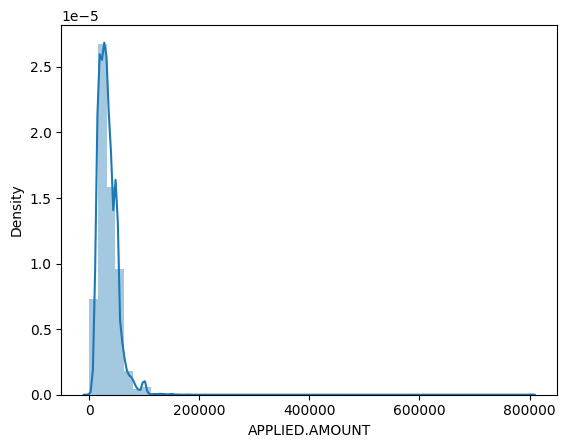

In [268]:
sns.distplot(X_numerical["APPLIED.AMOUNT"])

<Axes: >

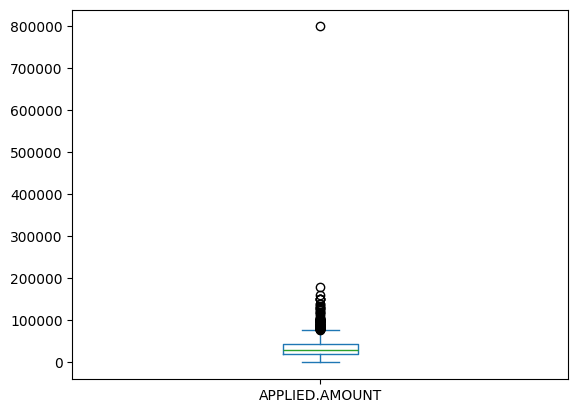

In [270]:
X_numerical["APPLIED.AMOUNT"].plot(kind='box')

In [272]:
X_numerical["APPLIED.AMOUNT"].describe()

count      7755.000000
mean      34209.930883
std       18953.076510
min          10.000000
25%       21000.000000
50%       30000.000000
75%       43870.000000
max      800000.000000
Name: APPLIED.AMOUNT, dtype: float64

In [274]:
Q3_aa = X_numerical["APPLIED.AMOUNT"].describe()["75%"]
Q1_aa = X_numerical["APPLIED.AMOUNT"].describe()["25%"]
IQR_aa = Q3_aa - Q1_aa
max_value_aa = Q3_aa + 1.5*IQR_aa

In [276]:
max_value

15.0

In [278]:
X_numerical["APPLIED.AMOUNT"] = X_numerical["APPLIED.AMOUNT"].apply(lambda x: max_value_aa if x >= max_value_aa else x)

<Axes: >

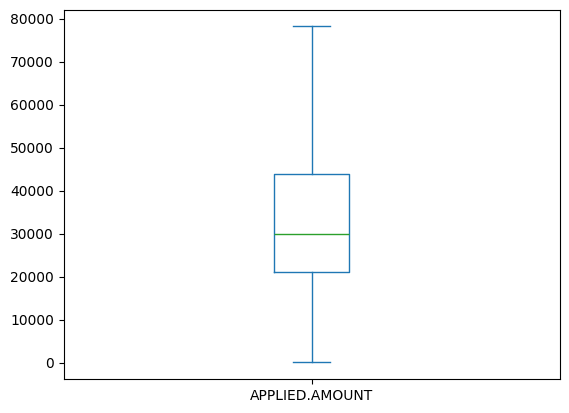

In [280]:
X_numerical["APPLIED.AMOUNT"].plot(kind='box')

<Axes: xlabel='APPLIED.AMOUNT', ylabel='Density'>

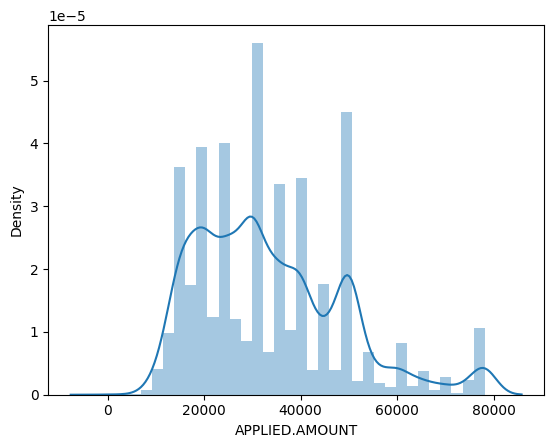

In [282]:
sns.distplot(X_numerical["APPLIED.AMOUNT"])

<Axes: xlabel='LOAN.TENOR', ylabel='Density'>

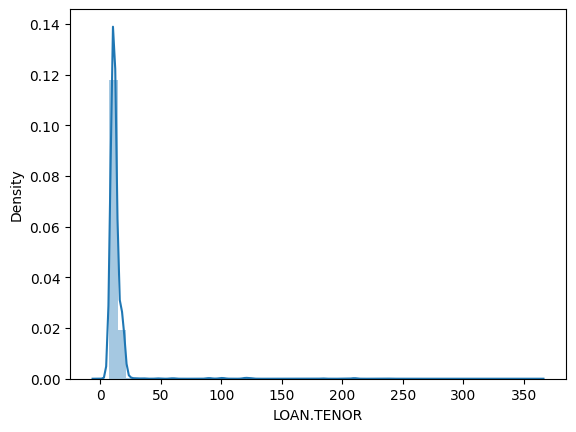

In [284]:
sns.distplot(X_numerical["LOAN.TENOR"])

<Axes: >

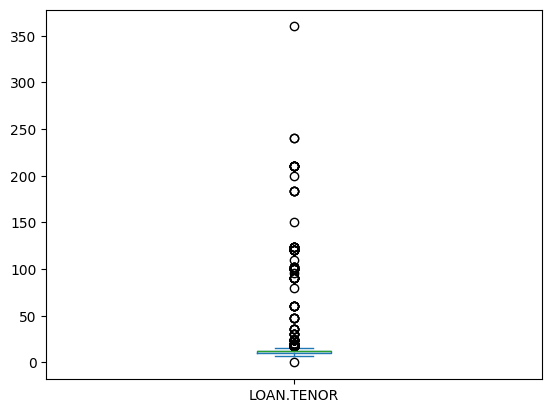

In [286]:
X_numerical["LOAN.TENOR"].plot(kind='box')

In [288]:
Q3_lt = X_numerical["LOAN.TENOR"].describe()["75%"]
Q1_lt = X_numerical["LOAN.TENOR"].describe()["25%"]
IQR_lt = Q3_lt - Q1_lt
max_value_lt = Q3_lt + 1.5*IQR_lt

X_numerical["LOAN.TENOR"] = X_numerical["LOAN.TENOR"].apply(lambda x: max_value_lt if x >= max_value_lt else x)

<Axes: xlabel='LOAN.TENOR', ylabel='Density'>

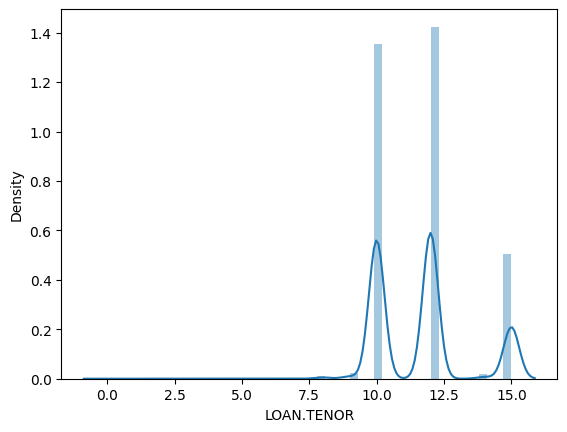

In [290]:
sns.distplot(X_numerical["LOAN.TENOR"])

<Axes: xlabel='NoOfIds', ylabel='Density'>

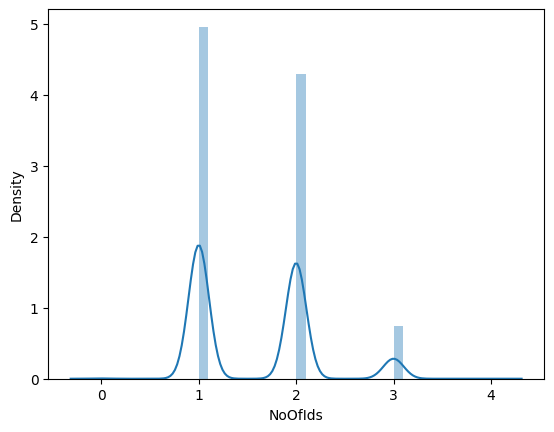

In [294]:
sns.distplot(X_numerical["NoOfIds"])

In [296]:
funal_numerical_features = ["APPLICATION.SCORE","RESIDENTIAL.ADDRESS.SCORE","APPLIED.AMOUNT","LOAN.TENOR","NoOfIds"]

In [298]:
X_numerical_s = X_numerical[funal_numerical_features]

## Feature scaling 

In [301]:
from sklearn.preprocessing import StandardScaler

In [303]:
std_scaler = StandardScaler()
X_numerical_scaled = std_scaler.fit_transform(X_numerical_s)

In [305]:
X_numerical_scaled

array([[ 0.65046231,  0.86687585, -0.37348761, -0.9327275 , -0.91679974],
       [ 1.76955048,  0.58900234,  0.87010497,  0.22201416, -0.91679974],
       [ 2.77386038,  0.42058345, -0.24258313,  0.22201416, -0.91679974],
       ...,
       [-0.95643351, -2.18726121, -0.60257046,  0.22201416,  0.67233347],
       [ 0.10526552,  1.26797408, -0.24258313,  0.22201416, -0.91679974],
       [-0.95643351,  0.27546781,  1.06646169,  1.95412665, -0.91679974]])

In [311]:
X.columns

Index(['APPLICATION.ID', 'DEALER.ID', 'MARITAL.STATUS', 'GENDER', 'AGE',
       'EDUCATION', 'RESIDENCE.TYPE', 'CITY', 'STATE', 'ZIP.CODE',
       'EMPLOY.CONSTITUTION', 'PAN.STATUS', 'CIBIL.SCORE', 'APPLICATION.SCORE',
       'RESIDENTIAL.ADDRESS.SCORE', 'OFFICE.ADDRESS.SCORE', 'APPLIED.AMOUNT',
       'LOAN.TENOR', 'PRIMARY.ASSET.CTG', 'PRIMARY.ASSET.MAKE',
       'PRIMARY.ASSET.MODELNO', 'VOTER_ID', 'DRIVING_LICENSE', 'AADHAAR',
       'PAN', 'BANK_PASSBOOK', 'NoOfIds'],
      dtype='str')

In [313]:
X_cat = X[["EDUCATION","RESIDENCE.TYPE","CIBIL.SCORE"]]

In [315]:
X_cat.head()

,EDUCATION,RESIDENCE.TYPE,CIBIL.SCORE
0,EDUCATED,OWNED,Good
1,OTHERS,OWNED,Excellent
2,EDUCATED,OWNED,Excellent
3,EDUCATED,OWNED,No History
4,EDUCATED,OWNED,Excellent


In [317]:
X_cat_final = pd.get_dummies(X_cat,drop_first=True)

In [319]:
X_cat_final.head()

,EDUCATION_OTHERS,RESIDENCE.TYPE_RENTED,CIBIL.SCORE_Good,CIBIL.SCORE_No History,CIBIL.SCORE_Poor
0,False,False,True,False,False
1,True,False,False,False,False
2,False,False,False,False,False
3,False,False,False,True,False
4,False,False,False,False,False


In [323]:
X_cat_final.values

array([[False, False,  True, False, False],
       [ True, False, False, False, False],
       [False, False, False, False, False],
       ...,
       [False, False, False,  True, False],
       [ True, False, False, False, False],
       [ True, False, False,  True, False]])

In [325]:
X_processed = np.concatenate((X_numerical_scaled,X_cat_final.values),axis=1)

In [329]:
X_processed.shape

(7755, 10)

## Model building

In [348]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.svm import SVC

In [336]:
from sklearn.linear_model import LogisticRegression

In [334]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, train_size=0.8, random_state=7)

In [338]:
lr = LogisticRegression()

In [346]:
kf = StratifiedKFold(n_splits=10, random_state=12, shuffle=True)
cv_results = cross_val_score(lr,X_train,y_train,scoring="accuracy",cv=kf)
print(cv_results.mean(), " ", cv_results.std())

0.8020674250688276   0.019127234977149844


In [354]:
model = SVC()
kf = StratifiedKFold(n_splits=10, random_state=482, shuffle=True)
cv_results = cross_val_score(model,X_train,y_train,scoring="accuracy",cv=kf)
print(cv_results.mean(), " ", cv_results.std())

0.7975525946704067   0.013582856489396365
